# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/TMDB_Movie/TMDB_movie_dataset_v11.csv")
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [4]:
# Check how many rows and columns

df.shape

(1383631, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383631 entries, 0 to 1383630
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1383631 non-null  int64  
 1   title                 1383613 non-null  object 
 2   vote_average          1383631 non-null  float64
 3   vote_count            1383631 non-null  int64  
 4   status                1383631 non-null  object 
 5   release_date          1086154 non-null  object 
 6   revenue               1383631 non-null  int64  
 7   runtime               1383631 non-null  int64  
 8   adult                 1383631 non-null  bool   
 9   backdrop_path         346552 non-null   object 
 10  budget                1383631 non-null  int64  
 11  homepage              142778 non-null   object 
 12  imdb_id               660386 non-null   object 
 13  original_language     1383631 non-null  object 
 14  original_title        1383613 non-

In [6]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.383631e+06,1.383631e+06,1.383631e+06,1.383631e+06,1.383631e+06,1.383631e+06,1.383631e+06
mean,8.795114e+05,1.589231e+00,1.550749e+01,6.262722e+05,4.438497e+01,2.398163e+05,1.036931e+00
std,4.673915e+05,2.877213e+00,2.887755e+02,1.924229e+07,6.079611e+01,5.105573e+06,6.891021e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.842630e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e-01
50%,8.954840e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.289982e+06,2.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.330000e-01
max,1.648774e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


# Data Cleaning

In [7]:
# Remove Duplicates

df = df.drop_duplicates(subset='id')

In [8]:
# Convert Release Date

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [9]:
# Extract Date Features

df['year'] = df['release_date'].dt.year
df['month'] = df['release_date'].dt.month
df['weekday'] = df['release_date'].dt.day_name()
df['decade'] = (df['year']//10)*10

In [10]:
# Remove Invalid Revenue

df = df[df['revenue'] > 0]

In [11]:
# Handle Missing Runtime

df['runtime'] = df['runtime'].fillna(df['runtime'].median())

In [12]:
# Remove Unnecessary Columns

df.drop(['poster_path','backdrop_path'],axis=1,inplace=True,errors='ignore')

In [13]:
# Split Genres

df['genres'] = df['genres'].str.split(',')
df = df.explode('genres')

In [14]:
df['production_companies'] = df['production_companies'].str.split(',')
df_companies = df.explode('production_companies')

df['production_countries'] = df['production_countries'].str.split(',')
df_countries = df.explode('production_countries')

df['spoken_languages'] = df['spoken_languages'].str.split(',')
df_languages = df.explode('spoken_languages')

df['keywords'] = df['keywords'].str.split(',')
df_keywords = df.explode('keywords')

# EXPLORATORY DATA ANALYSIS

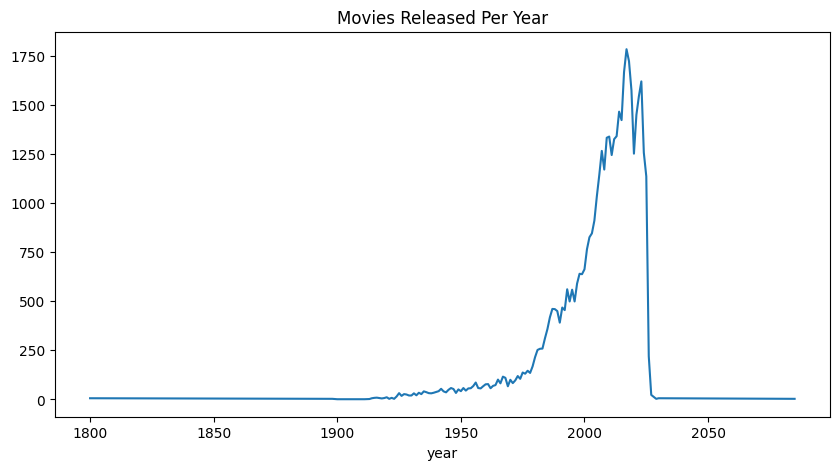

In [15]:
# Movies per Year

movies_per_year = df.groupby('year')['id'].count()

plt.figure(figsize=(10,5))
movies_per_year.plot()
plt.title("Movies Released Per Year")
plt.show()

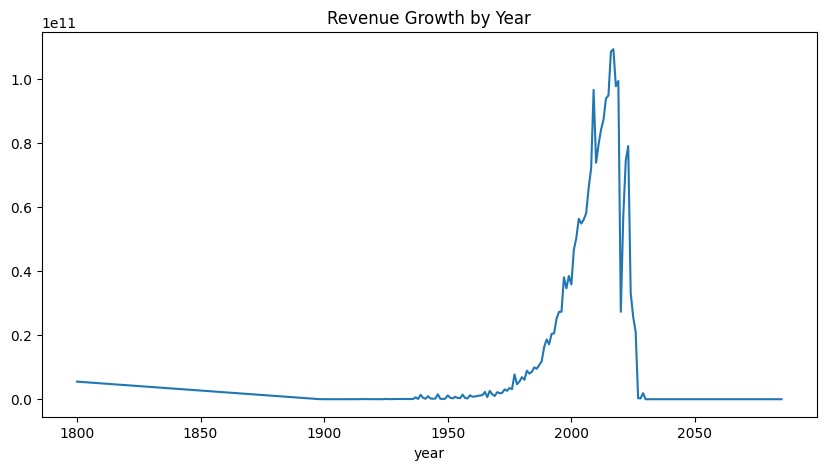

In [16]:
# Revenue per Year

revenue_year = df.groupby('year')['revenue'].sum()

plt.figure(figsize=(10,5))
revenue_year.plot()
plt.title("Revenue Growth by Year")
plt.show()

In [17]:
# Most Productive Decade

df['decade'].value_counts().sort_index()

,count
decade,
1800.0,6
1890.0,3
1900.0,2
1910.0,38
1920.0,162
1930.0,308
1940.0,455
1950.0,593
1960.0,830


In [18]:
# Top 50 Highest Revenue Movies

top_movies = df.sort_values('revenue',ascending=False).head(50)

top_movies[['title','revenue']]

,title,revenue
523552,In the Virtual End (Linkin Park HL2 music video),4999999999
847598,babben: the movie,4999999999
523552,In the Virtual End (Linkin Park HL2 music video),4999999999
706613,Juliet and Romeo - 1231 ☆*: .｡. o(≧▽≦)o .｡.:*☆...,4999999999
523552,In the Virtual End (Linkin Park HL2 music video),4999999999
786517,Macbeth's Ambition,3477779998
786517,Macbeth's Ambition,3477779998
786517,Macbeth's Ambition,3477779998
786517,Macbeth's Ambition,3477779998
786517,Macbeth's Ambition,3477779998


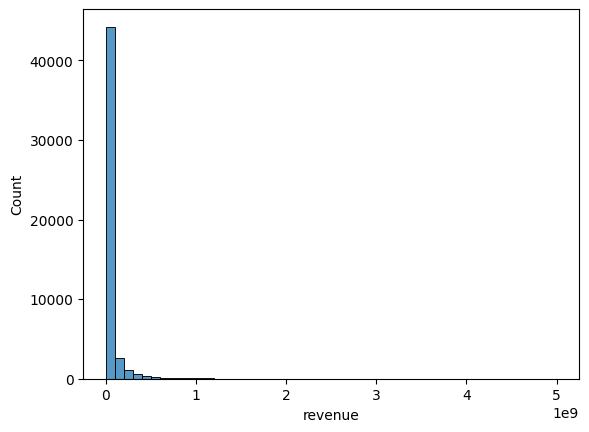

In [19]:
# Revenue Distribution

sns.histplot(df['revenue'],bins=50)
plt.show()

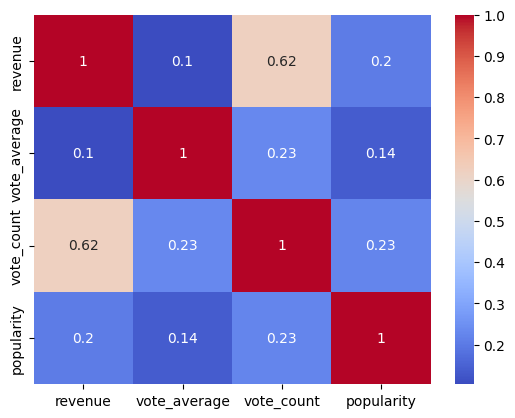

In [20]:
# Correlation Analysis

corr = df[['revenue','vote_average','vote_count','popularity']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

# Genre Analysis

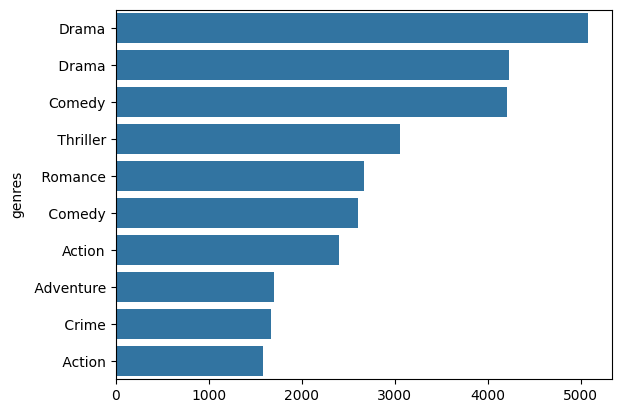

In [21]:
# Most Common Genres

genre_count = df['genres'].value_counts().head(10)

sns.barplot(x=genre_count.values,y=genre_count.index)
plt.show()

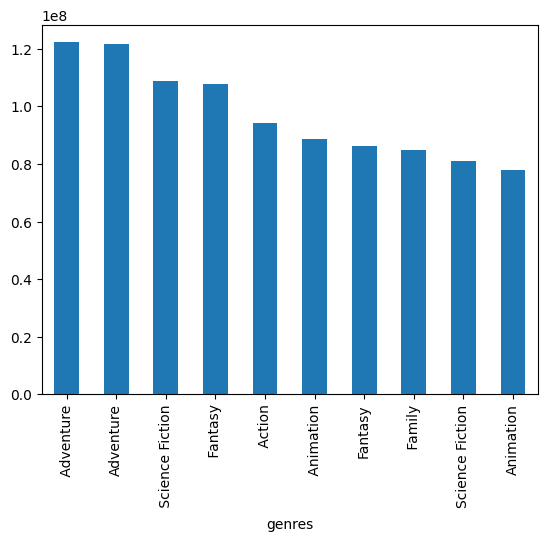

In [22]:
# Highest Revenue Genres

genre_revenue = df.groupby('genres')['revenue'].mean().sort_values(ascending=False).head(10)

genre_revenue.plot(kind='bar')
plt.show()

In [23]:
# Country Analysis

# Top Producing Countries

df_countries['production_countries'].value_counts().head(10)

,count
production_countries,
United States of America,18251
United States of America,5996
United Kingdom,2748
India,2196
United Kingdom,2155
France,1980
Canada,1689
Japan,1646
Germany,1301


In [24]:
# Revenue by Country

df_countries.groupby('production_countries')['revenue'].sum().sort_values(ascending=False)

,revenue
production_countries,
United States of America,1423201999166
United States of America,495312459980
United Kingdom,173173697230
United Kingdom,136916204731
China,101551813342
...,...
Burkina Faso,28
Antigua and Barbuda,20
Djibouti,9


In [25]:
# Language Analysis

df_languages['spoken_languages'].value_counts().head(10)

,count
spoken_languages,
English,26921
English,3286
French,2126
Spanish,2034
Spanish,1913
French,1552
Japanese,1510
Italian,1288
Mandarin,1210


In [26]:
# Production Company Intelligence

# Most Frequent Companies

df_companies['production_companies'].value_counts().head(20)

,count
production_companies,
Warner Bros. Pictures,1442
20th Century Fox,1132
Paramount,915
Universal Pictures,888
Universal Pictures,864
Columbia Pictures,767
Columbia Pictures,634
Canal+,617
Metro-Goldwyn-Mayer,610


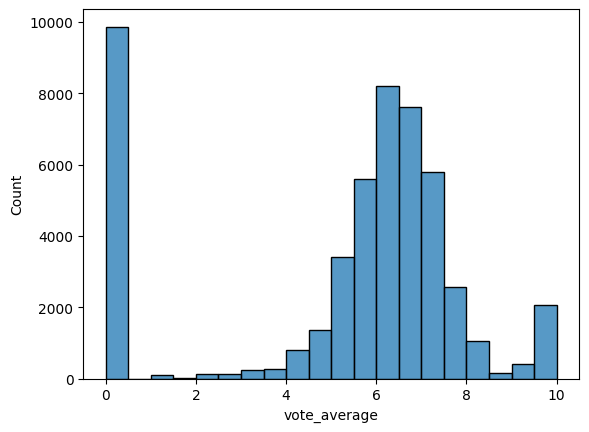

In [27]:
# Rating Distribution

sns.histplot(df['vote_average'],bins=20)
plt.show()

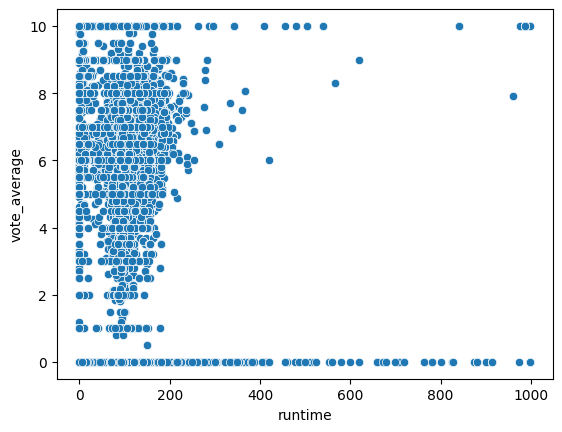

In [28]:
# Runtime vs Rating

sns.scatterplot(x='runtime',y='vote_average',data=df)
plt.show()

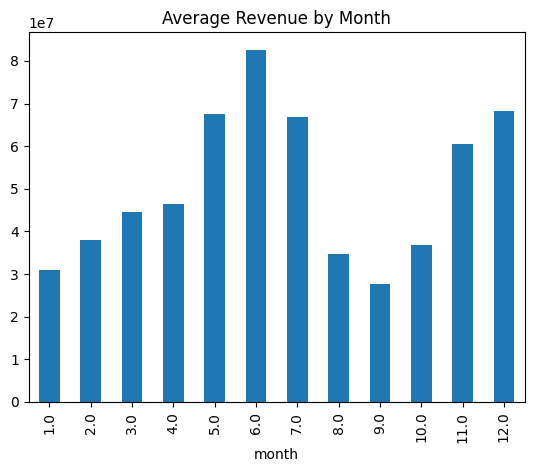

In [29]:
# Seasonality Analysis

month_revenue = df.groupby('month')['revenue'].mean()

month_revenue.plot(kind='bar')
plt.title("Average Revenue by Month")
plt.show()

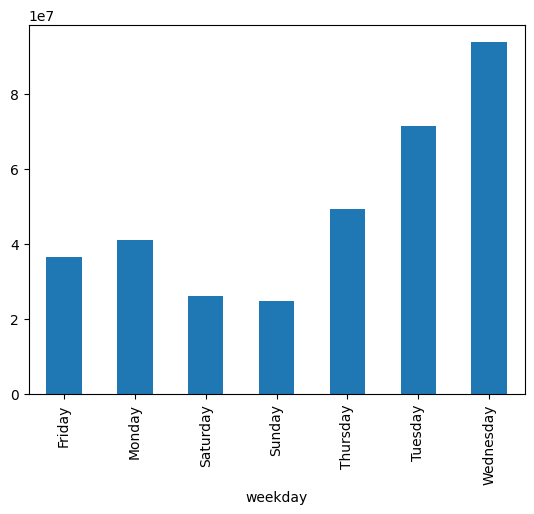

In [30]:
# Revenue by Weekday

df.groupby('weekday')['revenue'].mean().plot(kind='bar')
plt.show()

In [31]:
# Most Frequent Keywords

df_keywords['keywords'].value_counts().head(20)

,count
keywords,
murder,1840
based on novel or book,1828
woman director,1664
duringcreditsstinger,1220
based on novel or book,1217
sequel,1196
revenge,1146
california,1112
based on true story,1064


# MACHINE LEARNING
# PROJECT 1 — Revenue Prediction

In [32]:
# Features

features = df[['runtime','popularity','vote_count','vote_average','year','month']]
target = df['revenue']

In [33]:
# Train Test Split

X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2,random_state=42)

In [34]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [35]:
# Linear Regression

model = LinearRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("MAE:",mean_absolute_error(y_test,pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))
print("R2:",r2_score(y_test,pred))

MAE: 38486459.89372398
RMSE: 107232343.69347228
R2: 0.4151887022926607


In [36]:
# Random Forest

rf = RandomForestRegressor()

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

print("R2 Score:",r2_score(y_test,pred))

R2 Score: 0.8464383197834968


# PROJECT 2 — Movie Rating Prediction

In [37]:
features = df[['runtime','popularity','vote_count','year']]
target = df['vote_average']

X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("R2:",r2_score(y_test,pred))

R2: 0.9555771743679456


# PROJECT 3 — Blockbuster Classification

In [38]:
# Create Blockbuster Column

df['Blockbuster'] = (df['revenue'] > df['revenue'].quantile(0.80)).astype(int)

In [39]:
# Features

features = df[['runtime','popularity','vote_count','vote_average']]
target = df['Blockbuster']

In [40]:
# Train Model

X_train,X_test,y_train,y_test = train_test_split(features,target,test_size=0.2)

model = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42)

model.fit(X_train,y_train)

print("Accuracy:",model.score(X_test,y_test))

Accuracy: 0.9672789320485797


# PROJECT 4 — NLP on Overview & Tagline


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english',max_features=500)

text_features = tfidf.fit_transform(df['overview'].fillna(""))

# PROJECT 5 — Clustering Movie Types (unsupervised)

In [42]:
from sklearn.cluster import KMeans

X = df[['revenue','vote_average','popularity','runtime']]

kmeans = KMeans(n_clusters=4)

df['cluster'] = kmeans.fit_predict(X)

In [43]:
import pickle

# Save
pickle.dump(model, open("/content/drive/MyDrive/TMDB_Movie/model.pkl","wb"))
pickle.dump(tfidf, open("/content/drive/MyDrive/TMDB_Movie/vectorizer.pkl","wb"))

# Load
model = pickle.load(open("/content/drive/MyDrive/TMDB_Movie/model.pkl","rb"))
tfidf = pickle.load(open("/content/drive/MyDrive/TMDB_Movie/vectorizer.pkl","rb"))